# 1. System and Problem Definition
**Problem:** Estimating a fair market price for a residential property listing in Vietnam without manually comparing dozens of similar listings, helping buyers avoid overpaying and sellers/agents price competitively.

**System Statement:** The intelligent system is a price-estimation assistant that takes a raw property listing — physical measurements (area, frontage, road access), layout (floors, bedrooms, bathrooms), location (address/district), and qualitative attributes (direction, legal status, furniture state) — and converts it into a numerical feature vector. A trained regression model then maps this vector to a predicted price in billions of VND, giving users a fast, data-driven reference point before negotiating a real transaction.

# 2. Intelligent System Diagram
```mermaid
flowchart LR
    A["Input:<br/>Raw Property<br/>Listing Data"] --> B["Represent:<br/>Feature Vector<br/>(Scaled Numerics +<br/>One-Hot Categoricals)"]
    B --> C["Model:<br/>Trained ML<br/>Regressor"]
    C --> D["Predict:<br/>Continuous Price<br/>(Billion VND)"]
```

# 3. Dataset Source
The dataset is `vietnam_housing_dataset.csv`, a collection of Vietnamese residential real-estate listings.

**[TODO: paste the exact Kaggle/source URL here.]**

# 4. Dataset Description
- **Phenomenon:** The pricing behavior of the Vietnamese residential real-estate market, driven by property size, location, and quality attributes.
- **Observation:** A single property listing (one row = one house/apartment posted for sale).
- **Raw features (11):** Address, Area, Frontage, Access Road, House direction, Balcony direction, Floors, Bedrooms, Bathrooms, Legal status, Furniture state.
- **Target:** `Price` (billions of VND) — numerical, continuous.
- **Task:** Regression.
- **Observations:** 30,229 listings (after dropping rows with missing `Price`).
- **Numerical features:** Area, Frontage, Access Road, Floors, Bedrooms, Bathrooms.
- **Categorical features:** District (engineered from Address), House direction, Balcony direction, Legal status, Furniture state — 367 dimensions after one-hot encoding (incl. 342 districts).

# 5. Data Representation

| Feature | Type | Representation | Meaning |
| --- | --- | --- | --- |
| Area | Numerical | Real value | Property floor area (m²) |
| Frontage | Numerical | Real value | Width of the property facing the street (m) |
| Access Road | Numerical | Real value | Width of the road giving access to the property (m) |
| Floors | Numerical | Integer | Number of floors |
| Bedrooms | Numerical | Integer | Number of bedrooms |
| Bathrooms | Numerical | Integer | Number of bathrooms |
| District (from Address) | Categorical | One-hot encoded (342 categories) | District extracted from the raw address string |
| House direction | Categorical | One-hot encoded | Compass direction the house faces |
| Balcony direction | Categorical | One-hot encoded | Compass direction the balcony faces |
| Legal status | Categorical | One-hot encoded | Legal ownership status |
| Furniture state | Categorical | One-hot encoded | Furnishing level |

Missing numerical values are imputed with the column median; missing categorical values are filled with `'Unknown'` before encoding (missingness is substantial for several columns, e.g. Balcony direction 82.6%, House direction 70.3%, Furniture state 46.7%). Categorical columns are converted with `pd.get_dummies(drop_first=True)`. The target `Price` is transformed with `log1p` before training and inverted with `expm1` before computing evaluation metrics; all 367 input dimensions are standardized with `StandardScaler` fit on the training set only.

# 6. Feature and Target Analysis
Numerical features (Area, Frontage, Access Road, Floors, Bedrooms, Bathrooms) carry different physical scales, so distance/margin-based models (KNN, SVR) require standardization. Categorical features are one-hot encoded, with `District` contributing 342 sparse binary columns — this makes the encoded feature space high-dimensional (367-d) and mostly sparse. The target `Price` has a strong right skew (a small number of very expensive listings), which motivates modeling `log1p(Price)` during training and inverse-transforming predictions with `expm1` for evaluation in real VND.

# 7. Exploratory Data Analysis
Below we explore the distributions, correlations, and missingness patterns of the dataset features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="white")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#c3c2b7',
    'axes.grid': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.8,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ_BLUE = sns.light_palette("#2a78d6", as_cmap=True)
DIVERGING = LinearSegmentedColormap.from_list('diverging_br', ["#1c5cab", "#f0efec", "#e34948"])

df = pd.read_csv('vietnam_housing_dataset.csv')
display(df.head())


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


## 1. Distribution of the Target Variable (Price)
Understanding the distribution of property prices helps identify the average market rate and spot outliers (e.g., ultra-luxury properties).

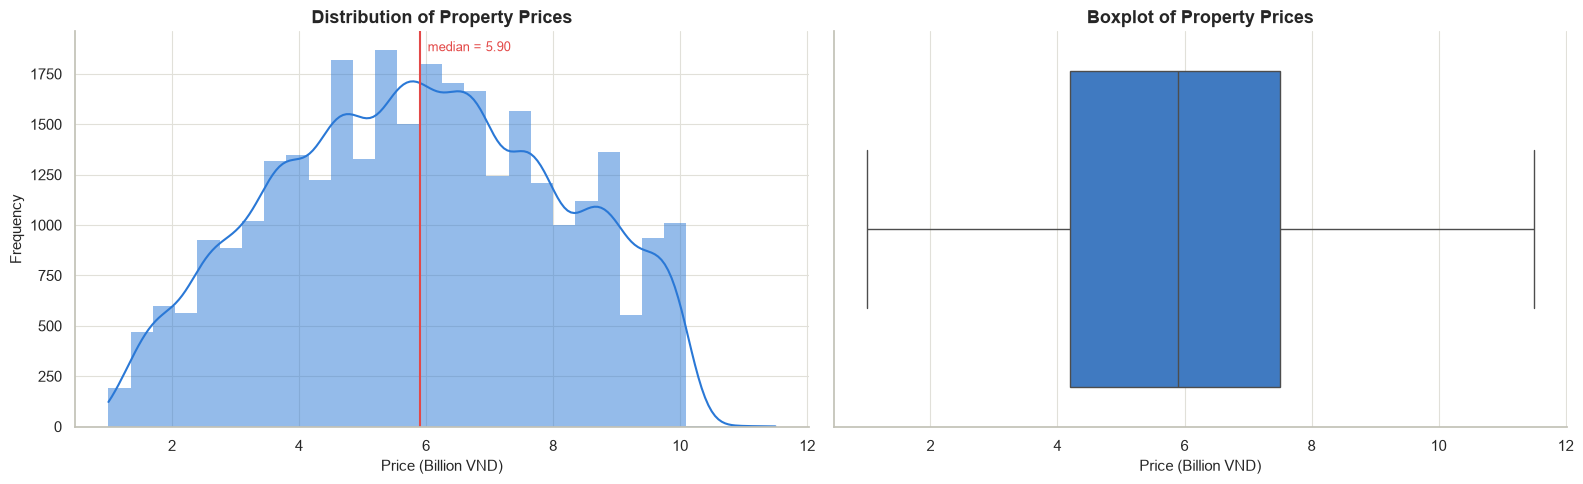

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['Price'], bins=30, kde=True, ax=ax[0], color=CATEGORICAL[0], edgecolor='none')
median_price = df['Price'].median()
ax[0].axvline(median_price, color=CATEGORICAL[7], linewidth=1.5)
ax[0].text(median_price, ax[0].get_ylim()[1] * 0.95, f'  median = {median_price:.2f}',
           color=CATEGORICAL[7], fontsize=9)
ax[0].set_title('Distribution of Property Prices')
ax[0].set_xlabel('Price (Billion VND)')
ax[0].set_ylabel('Frequency')

sns.boxplot(x=df['Price'], ax=ax[1], color=CATEGORICAL[0])
ax[1].set_title('Boxplot of Property Prices')
ax[1].set_xlabel('Price (Billion VND)')

plt.tight_layout()
plt.show()


## 2. Numerical Features Analysis
How do features like **Area** and **Frontage** relate to the **Price**? We will use scatter plots to visualize linear relationships and histograms to view feature distributions.

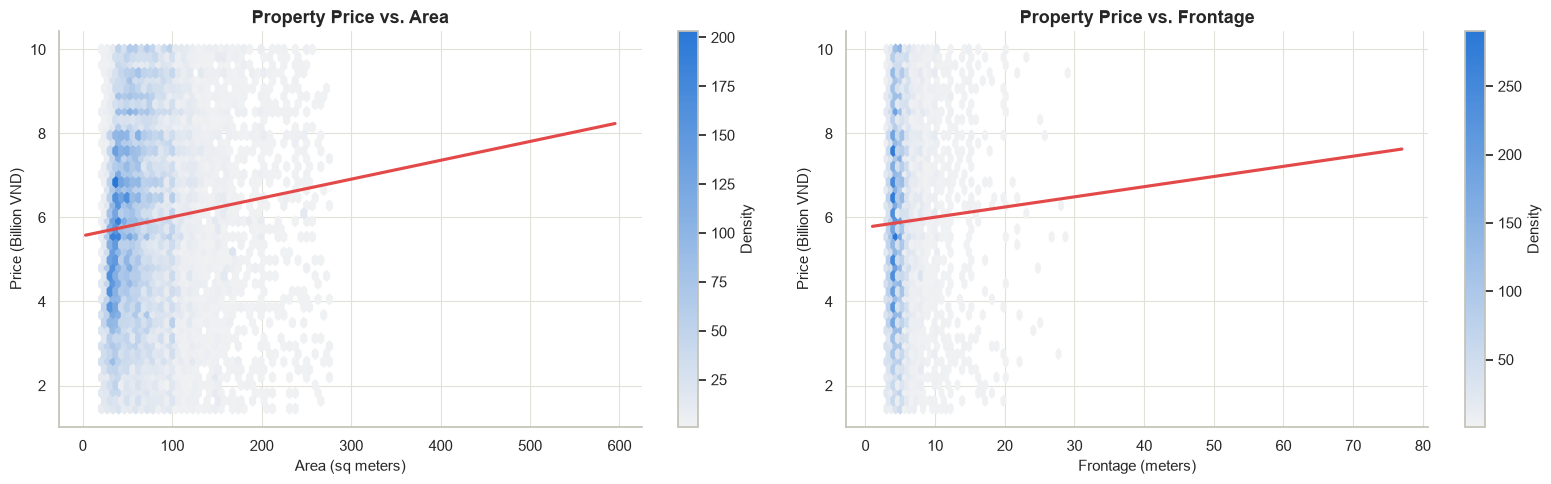

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

for axis, col, xlabel in zip(ax, ['Area', 'Frontage'], ['Area (sq meters)', 'Frontage (meters)']):
    sub = df[[col, 'Price']].dropna()
    x_lo, x_hi = sub[col].quantile([0.01, 0.99])
    y_lo, y_hi = sub['Price'].quantile([0.01, 0.99])
    hb = axis.hexbin(sub[col], sub['Price'], gridsize=40, cmap=SEQ_BLUE, mincnt=1,
                      extent=[x_lo, x_hi, y_lo, y_hi])
    sns.regplot(data=sub, x=col, y='Price', scatter=False, color=CATEGORICAL[7], ax=axis, ci=None)
    axis.set_title(f'Property Price vs. {col}')
    axis.set_xlabel(xlabel)
    axis.set_ylabel('Price (Billion VND)')
    plt.colorbar(hb, ax=axis, label='Density')

plt.tight_layout()
plt.show()


## 3. Categorical Features Analysis
How do **Furniture State**, **Legal Status**, and **House Direction** impact pricing? Boxplots are ideal for comparing the price distributions across different categories.

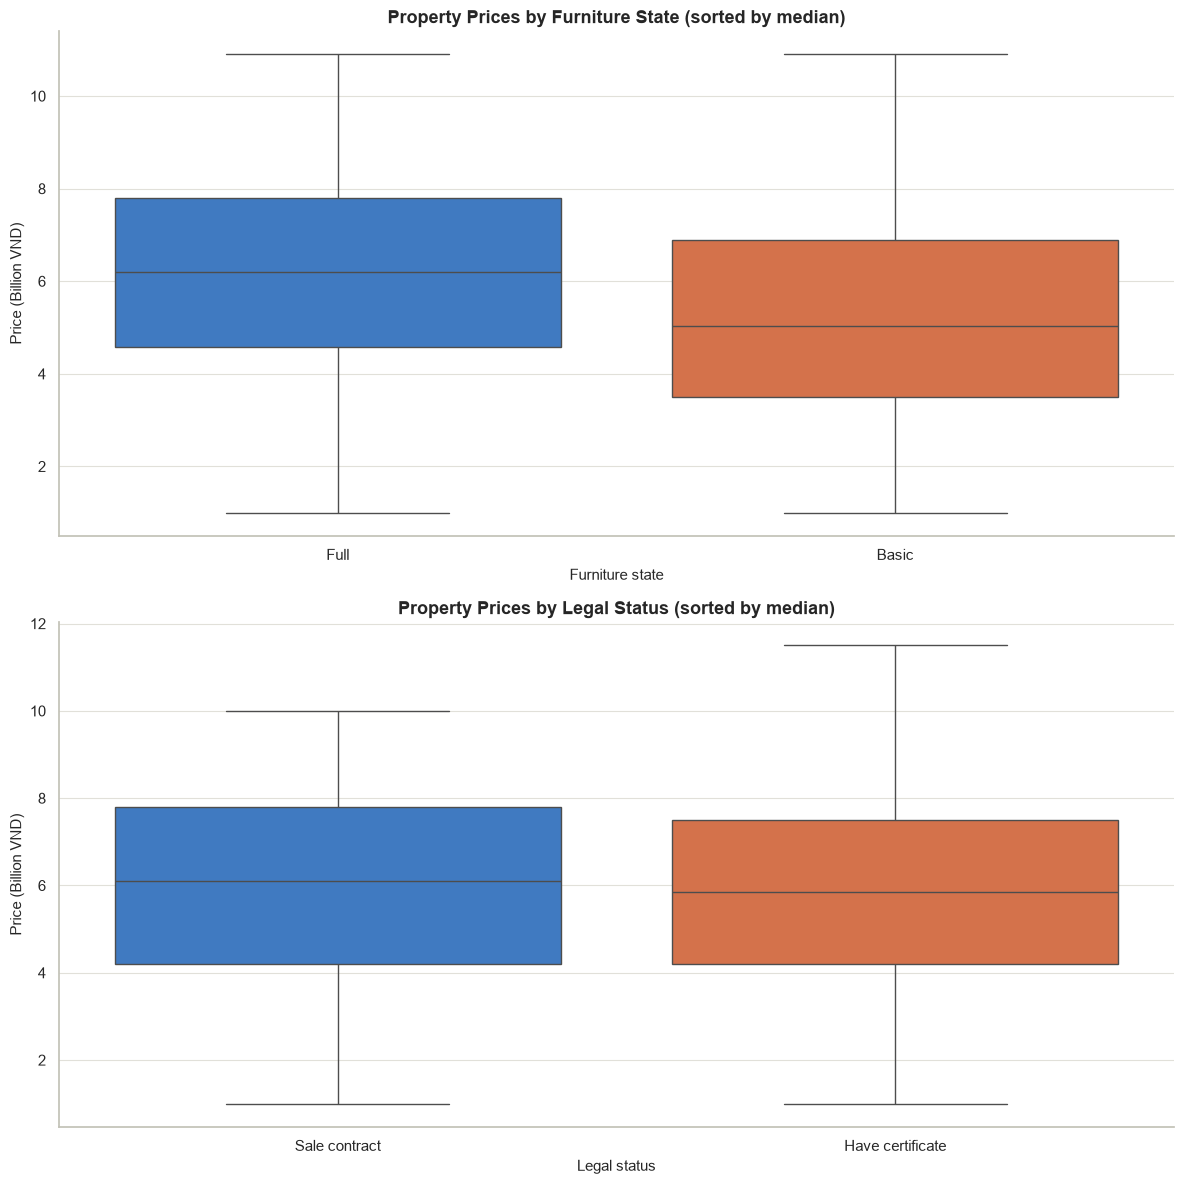

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(12, 12))

furn_order = df.groupby('Furniture state')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Furniture state', y='Price', order=furn_order, hue='Furniture state', hue_order=furn_order,
            palette=CATEGORICAL[:len(furn_order)], legend=False, ax=ax[0])
ax[0].set_title('Property Prices by Furniture State (sorted by median)')
ax[0].set_ylabel('Price (Billion VND)')

legal_order = df.groupby('Legal status')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Legal status', y='Price', order=legal_order, hue='Legal status', hue_order=legal_order,
            palette=CATEGORICAL[:len(legal_order)], legend=False, ax=ax[1])
ax[1].set_title('Property Prices by Legal Status (sorted by median)')
ax[1].set_ylabel('Price (Billion VND)')

plt.tight_layout()
plt.show()


## 4. Property Layout Analysis (Discrete Data)
Count plots and bar charts help us understand the standard configurations of homes on the market (e.g., the most common number of bedrooms and bathrooms).

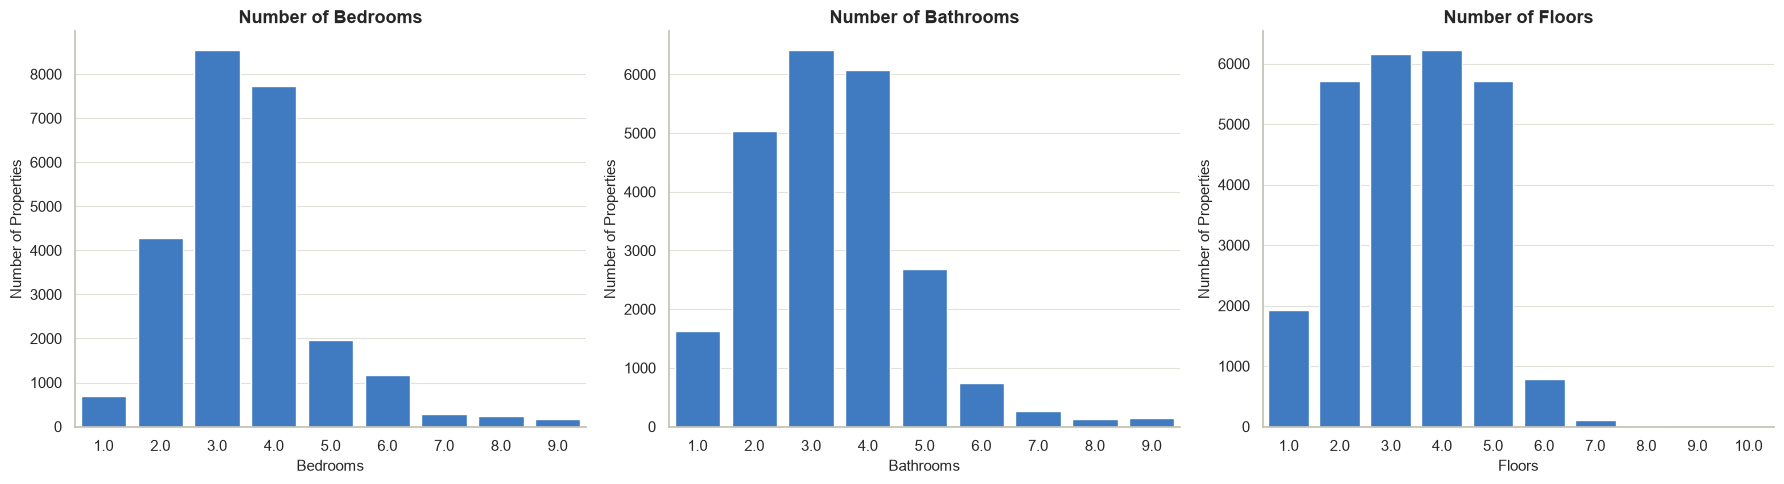

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for axis, col, title in zip(ax, ['Bedrooms', 'Bathrooms', 'Floors'],
                            ['Number of Bedrooms', 'Number of Bathrooms', 'Number of Floors']):
    sns.countplot(data=df, x=col, color=CATEGORICAL[0], ax=axis)
    axis.set_title(title)
    axis.set_xlabel(col)
    axis.set_ylabel('Number of Properties')

plt.tight_layout()
plt.show()


## 5. Correlation Matrix
A correlation heatmap calculates the Pearson correlation coefficient between all numerical variables. This helps identify multicollinearity (e.g., if Bedrooms and Area are highly correlated) and the strongest predictors of Price.

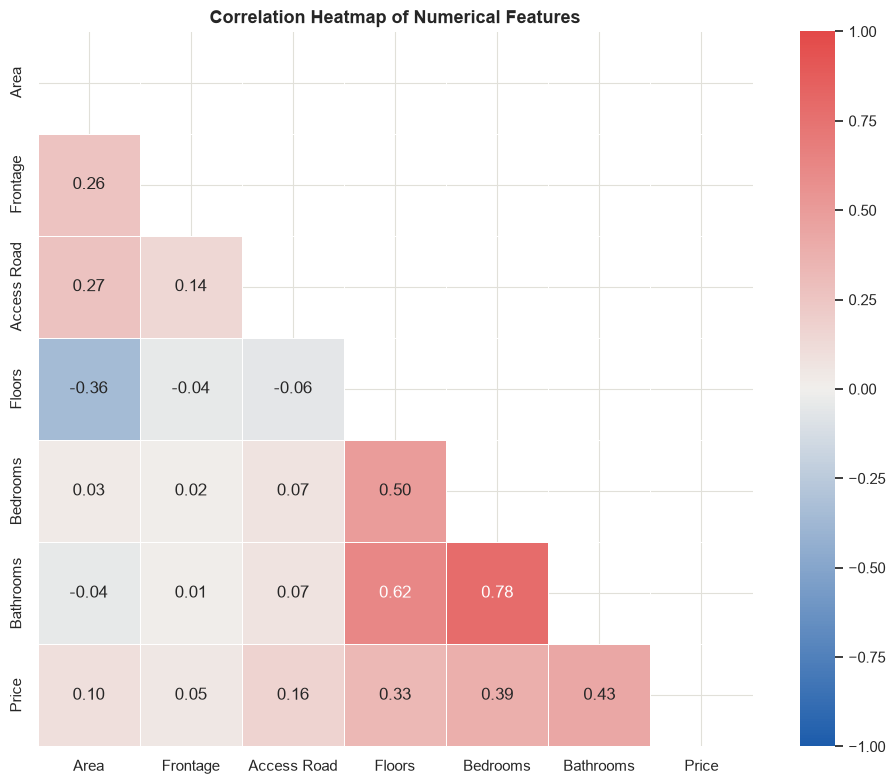

In [6]:
numerical_cols = ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms', 'Price']
corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap=DIVERGING, fmt=".2f",
            linewidths=0.5, linecolor='white', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


## 6. House and Balcony Direction Analysis
Visualizing the categorical direction data to see market supply (frequency of each direction) and market value (price distribution across directions). We will enforce a strict, hard-coded order for the directions for better readability.

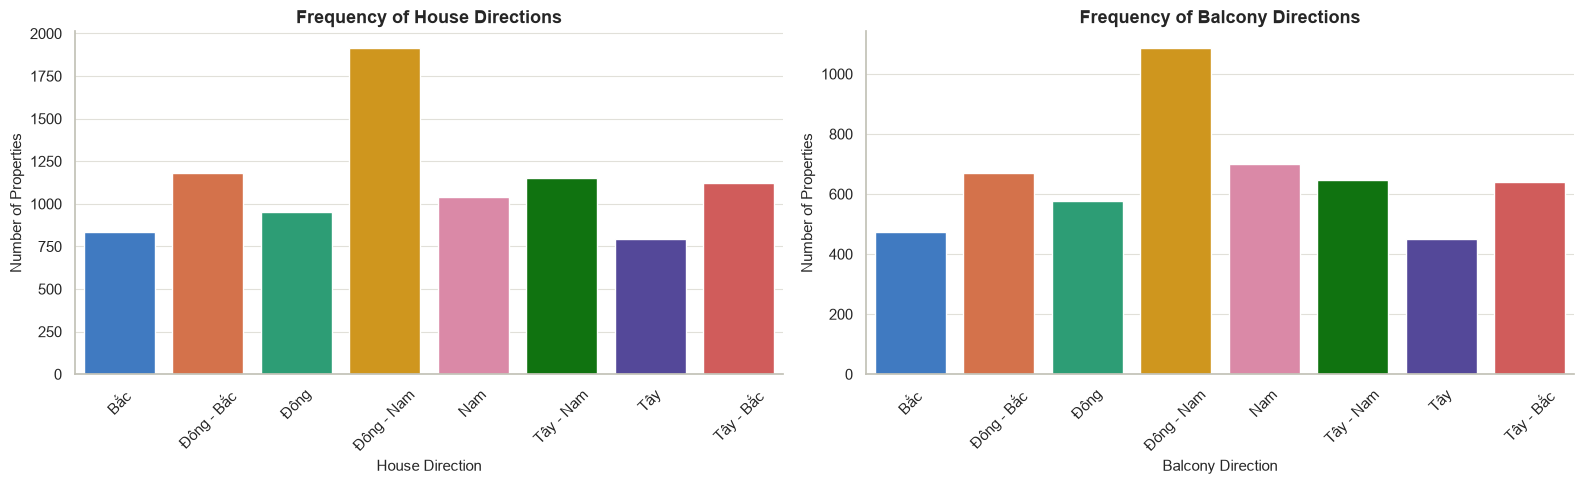

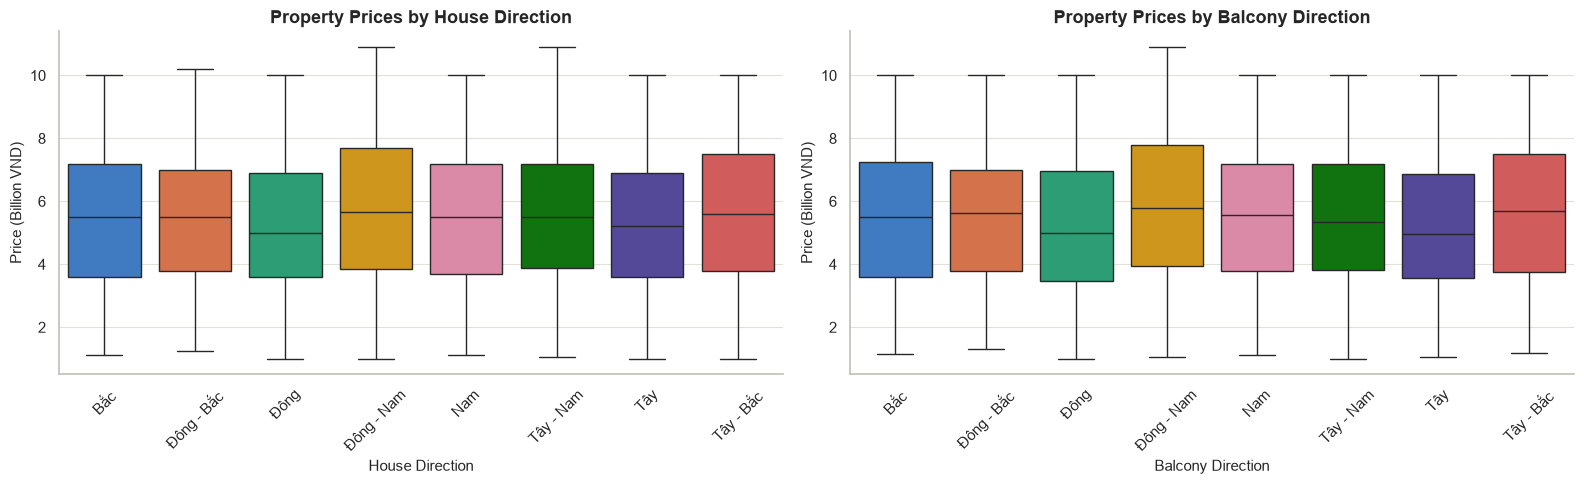

In [7]:
direction_order = ['Bắc', 'Đông - Bắc', 'Đông', 'Đông - Nam', 'Nam', 'Tây - Nam', 'Tây', 'Tây - Bắc']
direction_colors = CATEGORICAL[:len(direction_order)]

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df, x='House direction', order=direction_order, hue='House direction', hue_order=direction_order,
              palette=direction_colors, legend=False, ax=ax[0])
ax[0].set_title('Frequency of House Directions')
ax[0].set_xlabel('House Direction')
ax[0].set_ylabel('Number of Properties')
ax[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Balcony direction', order=direction_order, hue='Balcony direction', hue_order=direction_order,
              palette=direction_colors, legend=False, ax=ax[1])
ax[1].set_title('Frequency of Balcony Directions')
ax[1].set_xlabel('Balcony Direction')
ax[1].set_ylabel('Number of Properties')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x='House direction', y='Price', order=direction_order, hue='House direction', hue_order=direction_order,
            palette=direction_colors, legend=False, ax=ax[0])
ax[0].set_title('Property Prices by House Direction')
ax[0].set_xlabel('House Direction')
ax[0].set_ylabel('Price (Billion VND)')
ax[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='Balcony direction', y='Price', order=direction_order, hue='Balcony direction', hue_order=direction_order,
            palette=direction_colors, legend=False, ax=ax[1])
ax[1].set_title('Property Prices by Balcony Direction')
ax[1].set_xlabel('Balcony Direction')
ax[1].set_ylabel('Price (Billion VND)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 7. Geographical Feature Engineering & Visualization
The raw `Address` column contains strings that are too unique for a machine learning model to use effectively. However, in standard Vietnamese formatting, the **District** is usually the second-to-last item in the address string. 

We will:
1. Parse the strings to extract the District.
2. Visualize the supply (count) and market value (price distribution) across the most popular districts.

In [8]:
def extract_district(address):
    if pd.isna(address) or address == 'Unknown':
        return 'Unknown'
    parts = [part.strip() for part in str(address).split(',')]
    return parts[-2] if len(parts) >= 2 else 'Unknown'

df['District'] = df['Address'].apply(extract_district)
display(df[['Address', 'District']].head(10))


,Address,District
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",Văn Giang
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",Văn Giang
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",Văn Giang
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",Gò Vấp
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",Gò Vấp
5,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",Văn Giang
6,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",Văn Giang
7,"Dự án Him Lam Thường Tín, Huyện Thường Tín, Hà...",Huyện Thường Tín
8,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",Văn Giang
9,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",Văn Giang


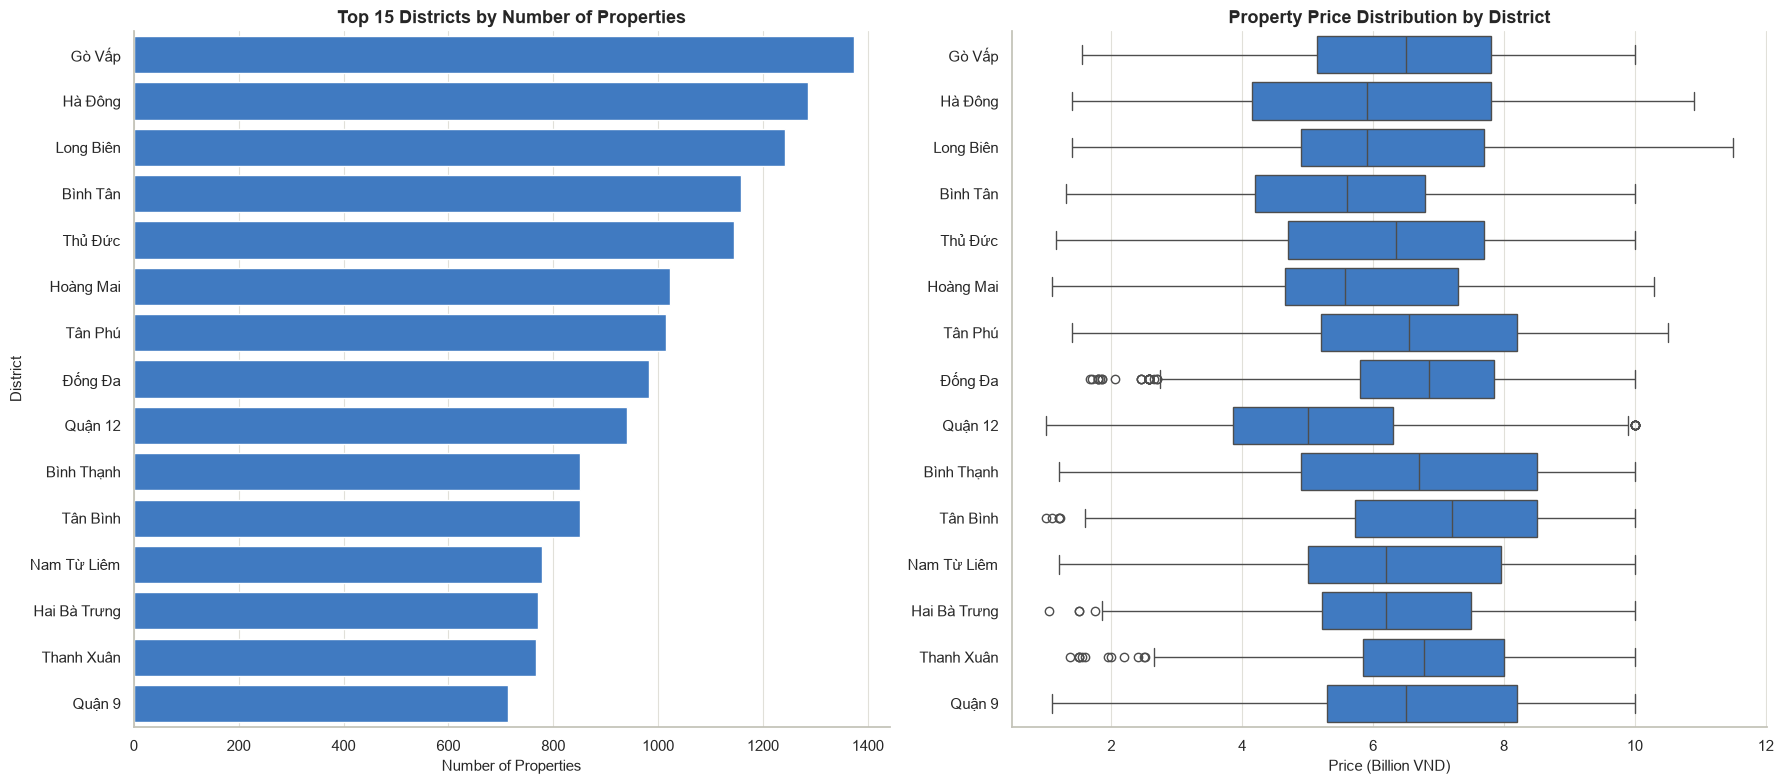

In [9]:
top_15_districts = df['District'].value_counts().nlargest(15).index
df_top_districts = df[df['District'].isin(top_15_districts)]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.countplot(data=df_top_districts, y='District', order=top_15_districts, color=CATEGORICAL[0], ax=axes[0])
axes[0].set_title('Top 15 Districts by Number of Properties')
axes[0].set_xlabel('Number of Properties')
axes[0].set_ylabel('District')

sns.boxplot(data=df_top_districts, x='Price', y='District', order=top_15_districts, color=CATEGORICAL[0], ax=axes[1])
axes[1].set_title('Property Price Distribution by District')
axes[1].set_xlabel('Price (Billion VND)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


## 8. Advanced Visualizations (Log Price, Missingness, Unit Price, and Interactions)
We will now add additional advanced visualizations:
1. **Target variable transformation** (Raw Price vs. Log Price)
2. **Missing data density**


## 8. Target Variable Transformation: Raw Price vs. Log Price
Description: This section visualizes the distribution of the target variable (Price) before and after applying a logarithmic transformation ($\log(1 + x)$).

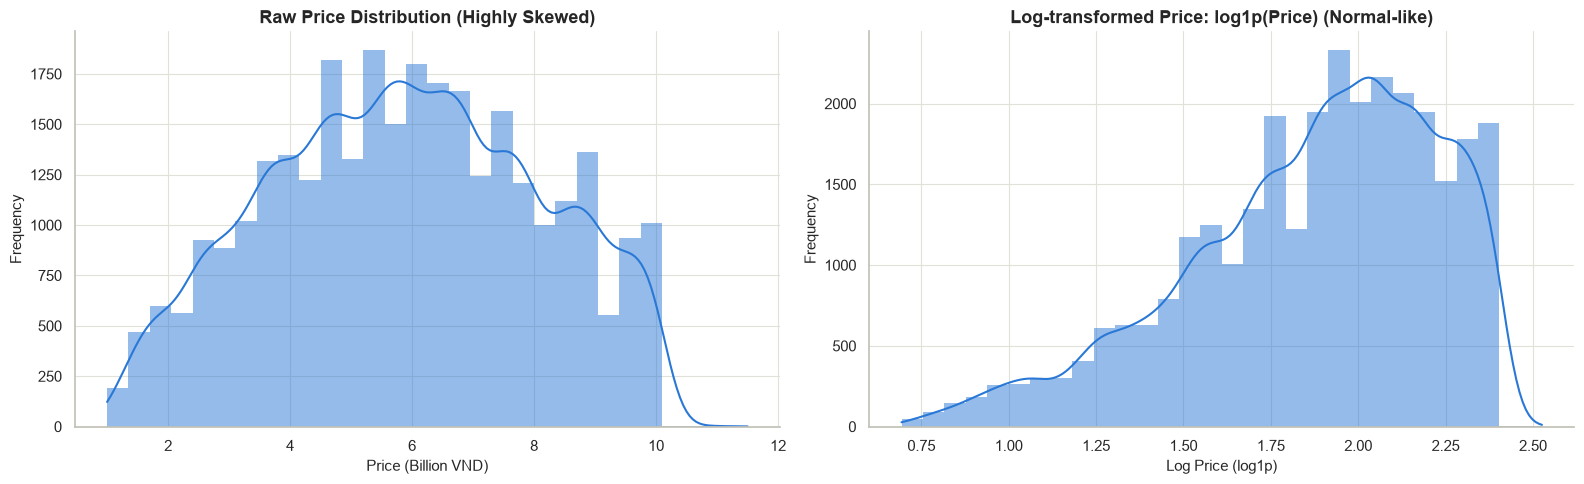

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['Price'], bins=30, kde=True, ax=axes[0], color=CATEGORICAL[0], edgecolor='none')
axes[0].set_title('Raw Price Distribution (Highly Skewed)')
axes[0].set_xlabel('Price (Billion VND)')
axes[0].set_ylabel('Frequency')

sns.histplot(np.log1p(df['Price']), bins=30, kde=True, ax=axes[1], color=CATEGORICAL[0], edgecolor='none')
axes[1].set_title('Log-transformed Price: log1p(Price) (Normal-like)')
axes[1].set_xlabel('Log Price (log1p)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## 9. Missing Data Density and Distribution
Description:
This section examines the concentration, patterns, and density of missing values across features in the dataset using visualization tools such as missingness heatmaps, dendrograms, and bar plots.

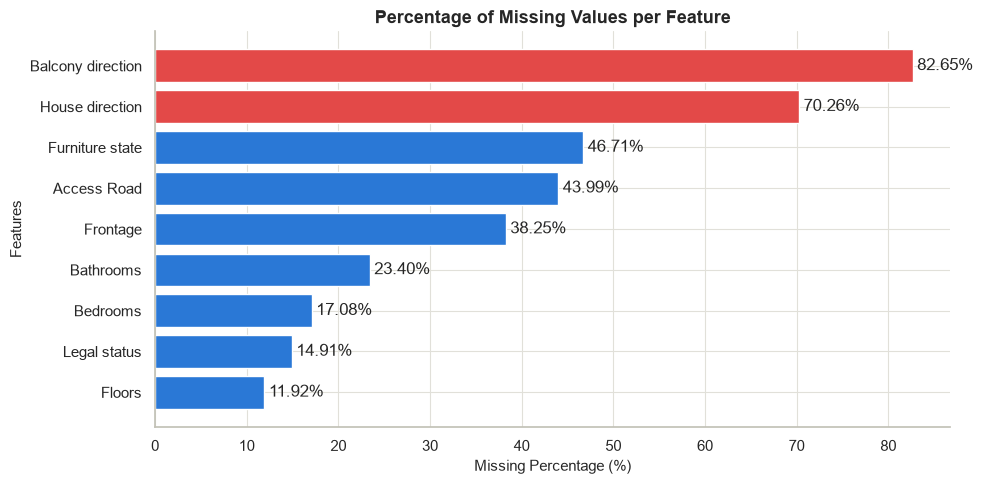

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

if not missing_percentage.empty:
    colors = [CATEGORICAL[7] if v > 50 else CATEGORICAL[0] for v in missing_percentage.values]
    plt.figure(figsize=(10, 5))
    bars = plt.barh(missing_percentage.index, missing_percentage.values, color=colors)
    plt.gca().invert_yaxis()
    plt.title('Percentage of Missing Values per Feature')
    plt.xlabel('Missing Percentage (%)')
    plt.ylabel('Features')
    for b, v in zip(bars, missing_percentage.values):
        plt.text(v + 0.5, b.get_y() + b.get_height() / 2, f"{v:.2f}%", va='center')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset (after cleaning/dropping).")


## 10. Bedrooms, Bathrooms, Access Road vs. Price
The count plots in Section 4 only display frequency distributions and do not reveal how these configurations impact property prices. We supplement this with box plots and scatter plots to clearly illustrate their relationships with Price.

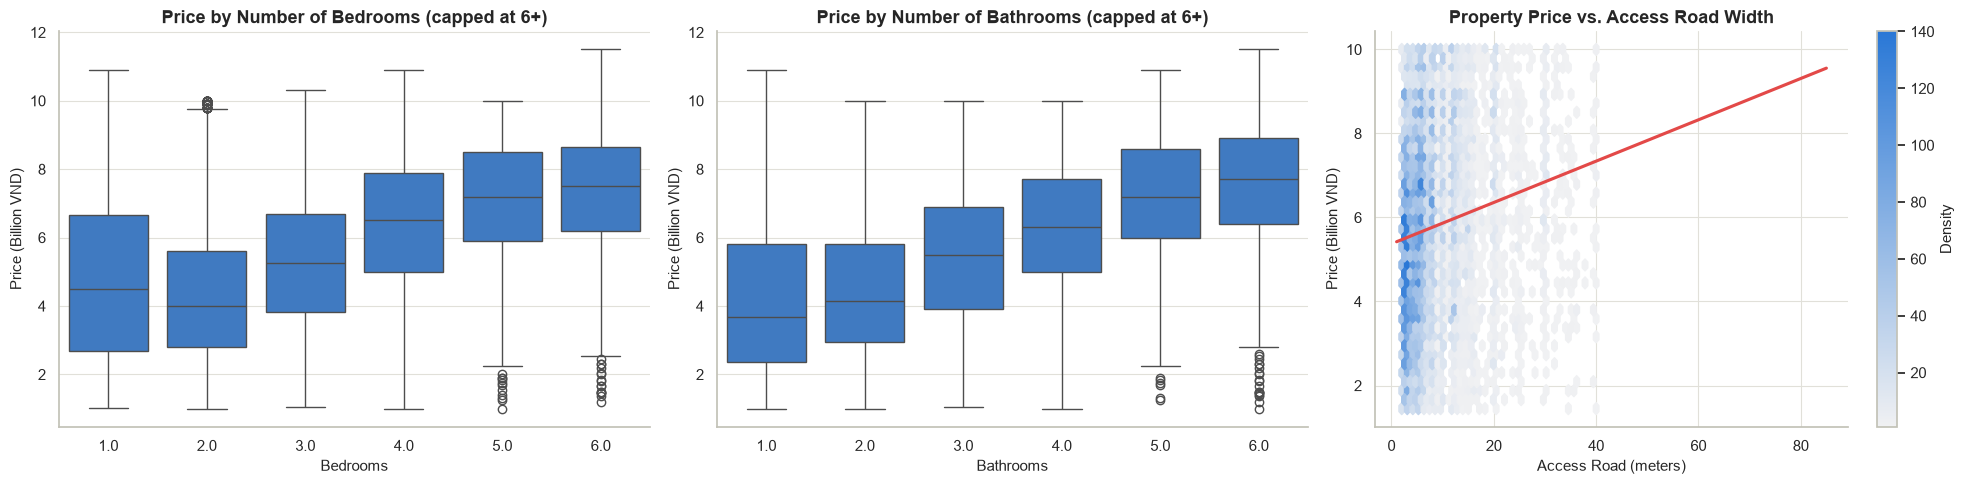

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

df_plot = df.copy()
df_plot['Bedrooms_capped'] = df_plot['Bedrooms'].apply(lambda x: min(int(x), 6) if pd.notna(x) else np.nan)
sns.boxplot(data=df_plot, x='Bedrooms_capped', y='Price', color=CATEGORICAL[0], ax=ax[0])
ax[0].set_title('Price by Number of Bedrooms (capped at 6+)')
ax[0].set_xlabel('Bedrooms')
ax[0].set_ylabel('Price (Billion VND)')

df_plot['Bathrooms_capped'] = df_plot['Bathrooms'].apply(lambda x: min(int(x), 6) if pd.notna(x) else np.nan)
sns.boxplot(data=df_plot, x='Bathrooms_capped', y='Price', color=CATEGORICAL[0], ax=ax[1])
ax[1].set_title('Price by Number of Bathrooms (capped at 6+)')
ax[1].set_xlabel('Bathrooms')
ax[1].set_ylabel('Price (Billion VND)')

sub = df[['Access Road', 'Price']].dropna()
x_lo, x_hi = sub['Access Road'].quantile([0.01, 0.99])
y_lo, y_hi = sub['Price'].quantile([0.01, 0.99])
hb = ax[2].hexbin(sub['Access Road'], sub['Price'], gridsize=35, cmap=SEQ_BLUE, mincnt=1,
                   extent=[x_lo, x_hi, y_lo, y_hi])
sns.regplot(data=sub, x='Access Road', y='Price', scatter=False, color=CATEGORICAL[7], ax=ax[2], ci=None)
ax[2].set_title('Property Price vs. Access Road Width')
ax[2].set_xlabel('Access Road (meters)')
ax[2].set_ylabel('Price (Billion VND)')
plt.colorbar(hb, ax=ax[2], label='Density')

plt.tight_layout()
plt.show()


## 11. Pairplot: Simultaneous Multivariable Relationships
A pairplot provides a comprehensive overview of pairwise relationships (scatter plots for each variable pair) between key features and Price simultaneously, rather than examining each pair in isolation as in Section 2

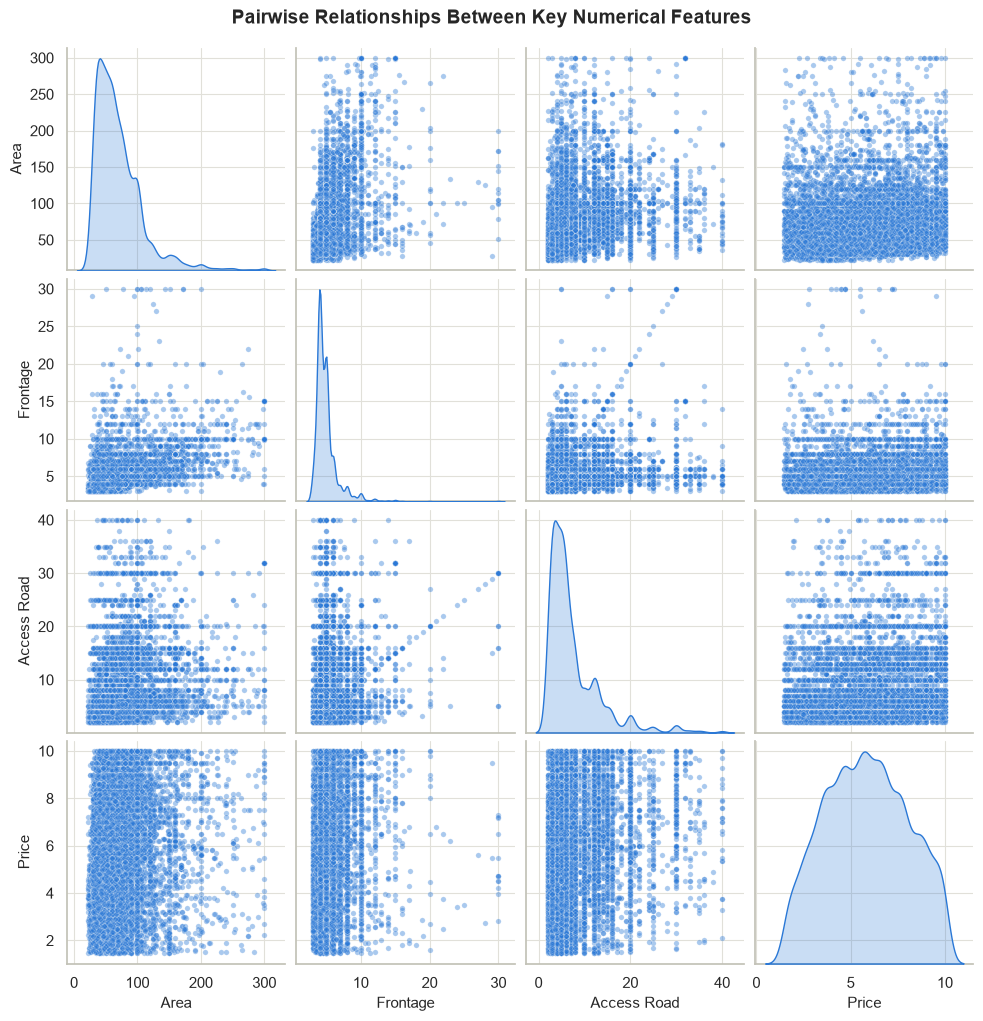

In [13]:
sample_df = df[['Area', 'Frontage', 'Access Road', 'Price']].dropna()
for col in sample_df.columns:
    lower, upper = sample_df[col].quantile([0.01, 0.99])
    sample_df = sample_df[(sample_df[col] >= lower) & (sample_df[col] <= upper)]

g = sns.pairplot(sample_df, diag_kind='kde',
                  plot_kws={'alpha': 0.4, 's': 15, 'color': CATEGORICAL[0]},
                  diag_kws={'color': CATEGORICAL[0]})
g.fig.suptitle('Pairwise Relationships Between Key Numerical Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()


## 12. Location Premium: Price per m² by District
Raw `Price` conflates two effects — property size and location desirability. Dividing by `Area` gives a **unit price** (price per m²) that isolates the location premium alone. This motivates keeping `District` as a model feature (342 categories) instead of dropping it for being high-cardinality: the location signal it carries is large and real, not noise.


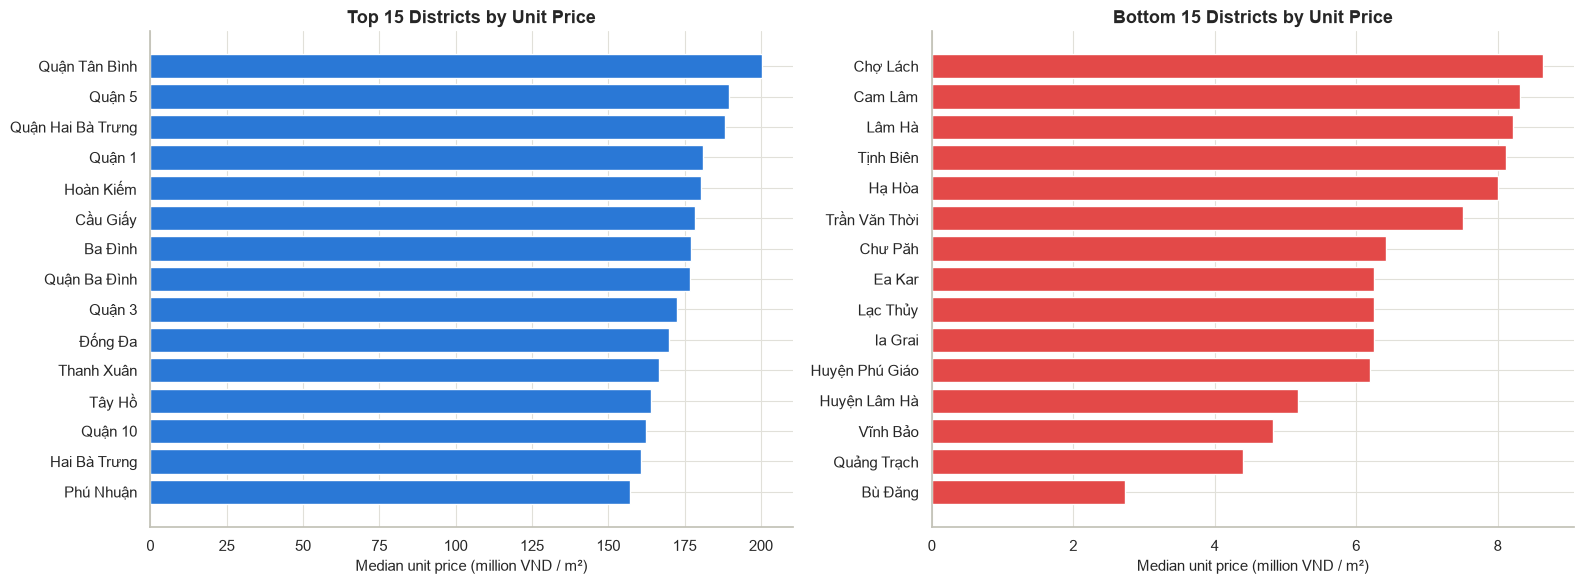

Unit-price gap between the most and least expensive district (top-15): 73.4x


In [14]:
df['Price_per_m2'] = df['Price'] / df['Area'] * 1000

top_n = 15
district_unit_price = (
    df[df['District'] != 'Unknown']
    .groupby('District')['Price_per_m2']
    .median()
    .sort_values(ascending=False)
)

top15 = district_unit_price.head(top_n)
bottom15 = district_unit_price.tail(top_n).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top15.index[::-1], top15.values[::-1], color=CATEGORICAL[0])
axes[0].set_title('Top 15 Districts by Unit Price')
axes[0].set_xlabel('Median unit price (million VND / m²)')

axes[1].barh(bottom15.index, bottom15.values, color=CATEGORICAL[7])
axes[1].set_title('Bottom 15 Districts by Unit Price')
axes[1].set_xlabel('Median unit price (million VND / m²)')

plt.tight_layout()
plt.show()

ratio = top15.iloc[0] / bottom15.iloc[0]
print(f"Unit-price gap between the most and least expensive district (top-15): {ratio:.1f}x")


## 13. Interaction: District x Legal Status on Unit Price
Does the legal-certificate price premium hold the same everywhere, or does it interact with location? A single overall boxplot (Section 3) cannot show this — it averages across all districts. This cross-tab heatmap reveals whether the effect of `Legal status` is district-dependent, which is exactly the kind of feature interaction that justifies using non-linear models (Random Forest, XGBoost) over Linear Regression.


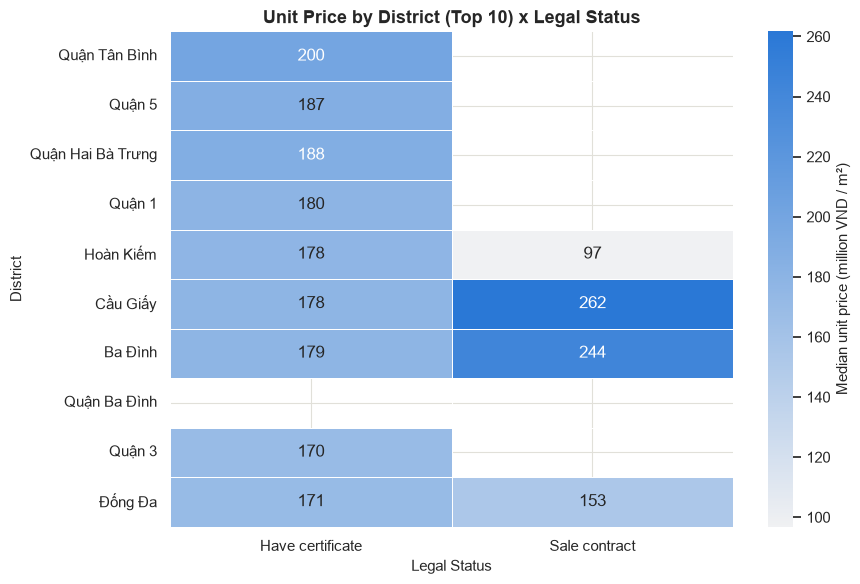

In [15]:
top10_districts = district_unit_price.head(10).index

pivot = (
    df[df['District'].isin(top10_districts)]
    .pivot_table(index='District', columns='Legal status', values='Price_per_m2', aggfunc='median')
    .reindex(top10_districts)
)

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap=SEQ_BLUE, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Median unit price (million VND / m²)'})
plt.title('Unit Price by District (Top 10) x Legal Status')
plt.ylabel('District')
plt.xlabel('Legal Status')
plt.tight_layout()
plt.show()


## 14. Price Segment Composition: Furniture State by Price Tier
Splitting listings into price quartiles (budget to luxury) and looking at the furnishing mix within each tier tests a domain hypothesis: do luxury properties skew toward full furnishing? A 100%-stacked bar (not raw counts) is the right form here because we care about *composition*, not volume — each tier has a different number of listings.


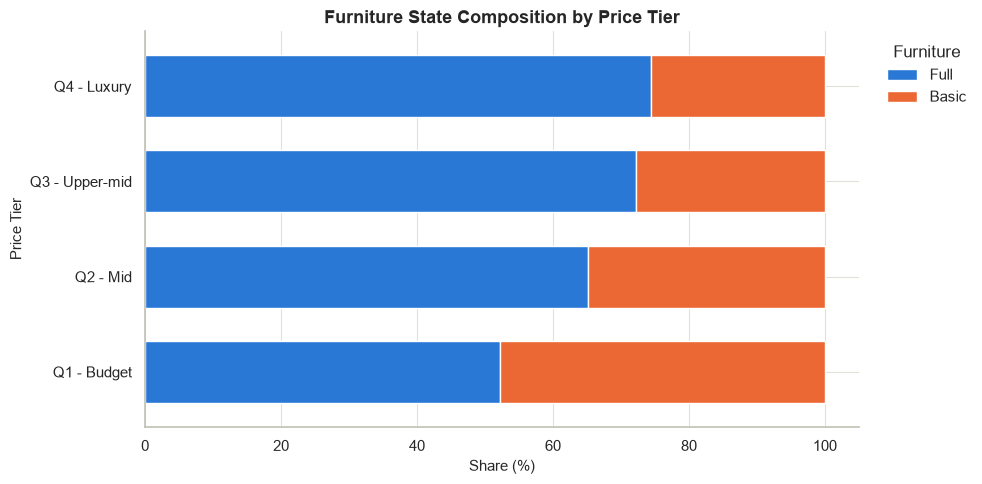

In [16]:
df['Price_tier'] = pd.qcut(df['Price'], q=4, labels=['Q1 - Budget', 'Q2 - Mid', 'Q3 - Upper-mid', 'Q4 - Luxury'])

comp = pd.crosstab(df['Price_tier'], df['Furniture state'], normalize='index') * 100
furniture_order = [c for c in ['Full', 'Basic', 'None', 'Unknown'] if c in comp.columns]
comp = comp[furniture_order]

fixed_colors = {'Full': CATEGORICAL[0], 'Basic': CATEGORICAL[1], 'None': CATEGORICAL[2], 'Unknown': '#c3c2b7'}
colors = [fixed_colors[c] for c in furniture_order]

ax = comp.plot(kind='barh', stacked=True, color=colors, figsize=(10, 5), width=0.65)
ax.set_xlabel('Share (%)')
ax.set_ylabel('Price Tier')
ax.set_title('Furniture State Composition by Price Tier')
ax.legend(title='Furniture', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()


## 15. Outlier Detection (IQR) — Bounded Price Range
The Report's Limitations section notes the model is trained on a bounded price range (1.0-11.5 billion VND) and is unlikely to generalize to ultra-luxury or micro transactions. This chart makes that claim visible: IQR-based outliers are highlighted (status color) against the normal population (neutral color), showing how much of the market sits outside the range the model was trained to predict well.


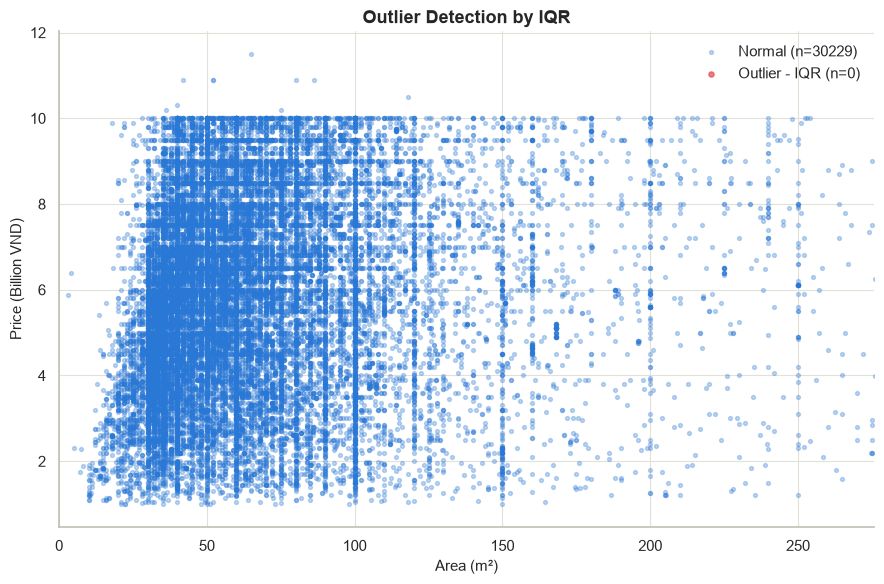

Outliers detected (IQR method): 0 (0.0% of dataset)
'Normal' price range (IQR): -0.75 - 12.45 billion VND


In [17]:
Q1, Q3 = df['Price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
df['Is_outlier'] = (df['Price'] < lower) | (df['Price'] > upper)

normal = df[~df['Is_outlier']]
outliers = df[df['Is_outlier']]

plt.figure(figsize=(9, 6))
plt.scatter(normal['Area'], normal['Price'], s=8, alpha=0.3, color=CATEGORICAL[0],
            label=f'Normal (n={len(normal)})')
plt.scatter(outliers['Area'], outliers['Price'], s=14, alpha=0.7, color=CATEGORICAL[7],
            label=f'Outlier - IQR (n={len(outliers)})')

plt.xlabel('Area (m²)')
plt.ylabel('Price (Billion VND)')
plt.title('Outlier Detection by IQR')
plt.legend(frameon=False)
plt.xlim(0, df['Area'].quantile(0.99))
plt.tight_layout()
plt.show()

print(f"Outliers detected (IQR method): {df['Is_outlier'].sum()} ({df['Is_outlier'].mean()*100:.1f}% of dataset)")
print(f"'Normal' price range (IQR): {lower:.2f} - {upper:.2f} billion VND")


# 8. Train/Test Split
We clean the data, extract `District` from the free-text `Address`, one-hot encode all categorical columns, log-transform the target, and split 80/20 (`random_state=42`). Numerical + one-hot features are standardized with `StandardScaler` fit only on the training set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv('vietnam_housing_dataset.csv')
df = df.dropna(subset=['Price'])

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('Price')
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

def extract_district(address):
    if pd.isna(address) or address == 'Unknown': return 'Unknown'
    parts = [part.strip() for part in str(address).split(',')]
    return parts[-2] if len(parts) >= 2 else 'Unknown'

df['District'] = df['Address'].apply(extract_district)

X = df.drop(['Price', 'Address'], axis=1, errors='ignore')
y = df['Price']
X_encoded = pd.get_dummies(X, drop_first=True)

y_log = np.log1p(df['Price'])
X_train, X_test, y_train_log, y_test_log = train_test_split(X_encoded, y_log, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# accumulates results across every model cell below
model_results = []


/var/folders/y_/p1kwrc014gbfjxlqsrtywg5c0000gn/T/ipykernel_35369/993365856.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


# 9. Baseline
Before evaluating the six regression models, we establish a baseline that always predicts the training set's mean price directly in raw VND space.

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_raw = np.expm1(y_train_log)
y_test_raw = np.expm1(y_test_log)

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_scaled, y_train_raw)
y_pred_dummy = dummy.predict(X_test_scaled)

mae_dummy = mean_absolute_error(y_test_raw, y_pred_dummy)
mse_dummy = mean_squared_error(y_test_raw, y_pred_dummy)
rmse_dummy = np.sqrt(mse_dummy)
r2_dummy = r2_score(y_test_raw, y_pred_dummy)

print(f'Baseline (predict mean) -> MAE: {mae_dummy:.4f} | MSE: {mse_dummy:.4f} | RMSE: {rmse_dummy:.4f} | R2: {r2_dummy:.4f}')

# 10. Model 1: Linear Regression

--- Tuning Linear Regression ---


Best Parameters: {'fit_intercept': True}
R-squared: 0.3735 | MAE: 1.3001 | RMSE: 1.7478
MAPE Accuracy: 74.0200


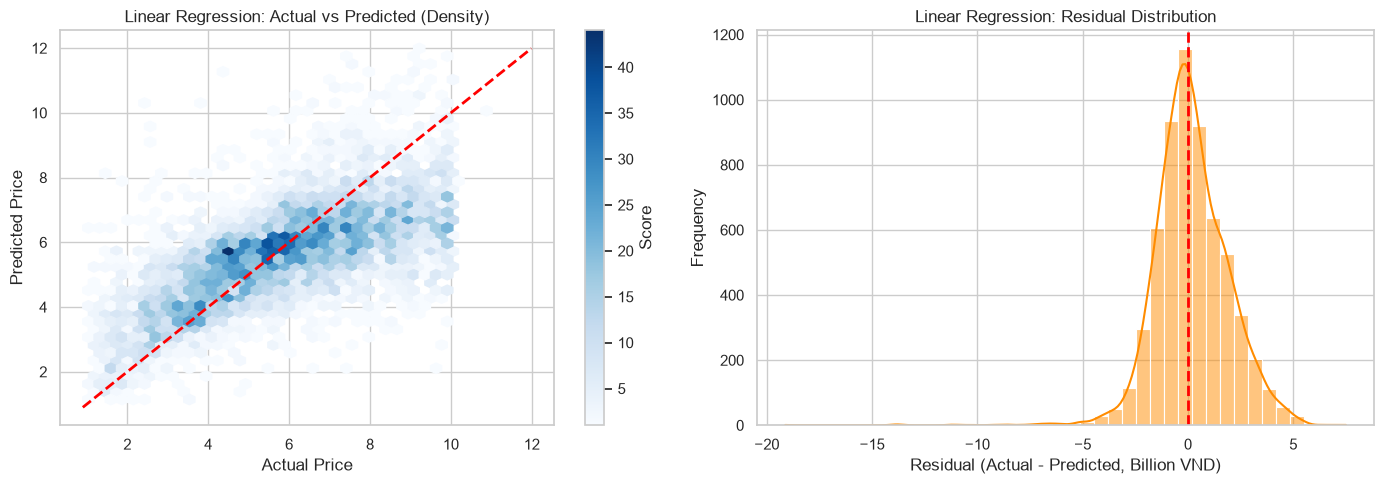

In [2]:
print("--- Tuning Linear Regression ---")
lr = LinearRegression()
param_grid_lr = {
    'fit_intercept': [True, False]
}

grid_lr = GridSearchCV(lr, param_grid_lr, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train_log)

print(f"Best Parameters: {grid_lr.best_params_}")
best_lr = grid_lr.best_estimator_
joblib.dump(best_lr, 'logistic_regression.pkl')

y_pred_log = best_lr.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_te = np.expm1(y_test_log)

r2 = r2_score(y_te, y_pred)
mae = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))

print(f"R-squared: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

mape = mean_absolute_percentage_error(y_te, y_pred)
accuracy_mape = max(0, (1 - mape) * 100)
print(f"MAPE Accuracy: {accuracy_mape:.4f}")
model_results.append({'Model': 'Linear Regression', 'R-squared': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE Accuracy': accuracy_mape})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
min_val, max_val = y_te.min() * 0.9, y_te.max() * 1.1

# hexbin avoids overplotting at ~6k test points; color = point density
hb = axes[0].hexbin(y_te, y_pred, gridsize=40, cmap='Blues', mincnt=1,
                     extent=[min_val, max_val, min_val, max_val])
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
axes[0].set_title("Linear Regression: Actual vs Predicted (Density)")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
plt.colorbar(hb, ax=axes[0], label='Score')

residuals = y_te - y_pred
sns.histplot(residuals, kde=True, bins=40, ax=axes[1], color='darkorange')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Linear Regression: Residual Distribution")
axes[1].set_xlabel("Residual (Actual - Predicted, Billion VND)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


# 11. Model 2: Support Vector Regressor (RBF Kernel)

--- Tuning SVR (RBF Kernel) ---


Best Parameters: {'C': 10, 'gamma': 'auto'}


R-squared: 0.5249 | MAE: 1.1195 | RMSE: 1.5220
MAPE Accuracy: 77.5406


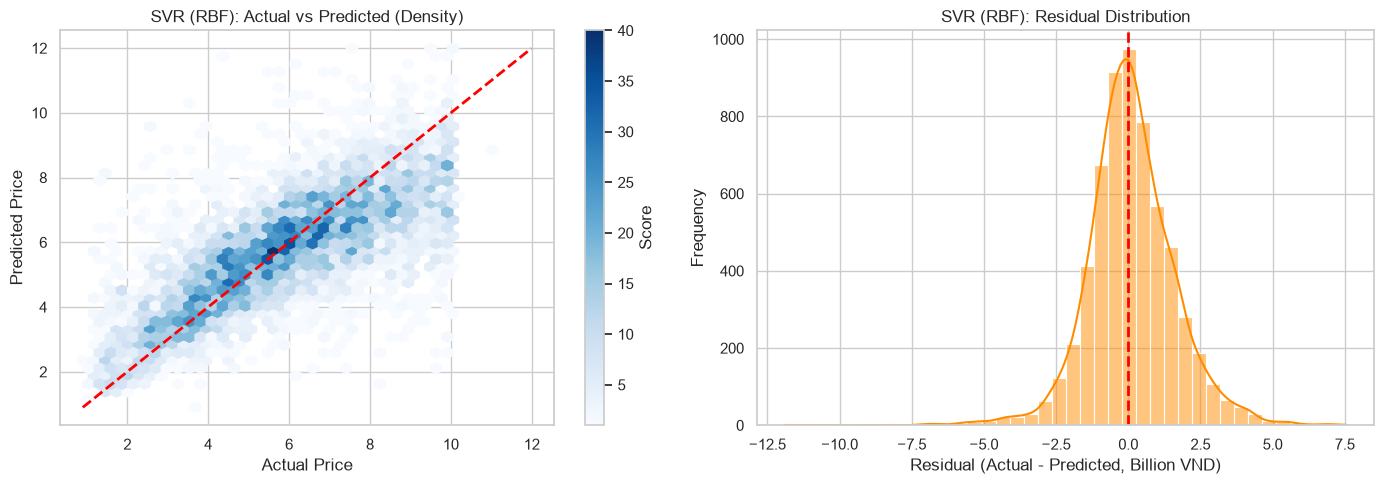

In [3]:
print("--- Tuning SVR (RBF Kernel) ---")
svr_rbf = SVR(kernel='rbf')
param_grid_rbf = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 1]
}

# tune on a 20% subsample for speed, then refit best params on the full training set
X_tune_rbf, _, y_tune_rbf, _ = train_test_split(X_train_scaled, y_train_log, train_size=0.20, random_state=42)

grid_rbf = GridSearchCV(svr_rbf, param_grid_rbf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rbf.fit(X_tune_rbf, y_tune_rbf)

print(f"Best Parameters: {grid_rbf.best_params_}")
best_rbf = grid_rbf.best_estimator_
best_rbf.fit(X_train_scaled, y_train_log)
joblib.dump(best_rbf, 'svr_rbf.pkl')

y_pred_log = best_rbf.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_te = np.expm1(y_test_log)

r2 = r2_score(y_te, y_pred)
mae = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))

print(f"R-squared: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

mape = mean_absolute_percentage_error(y_te, y_pred)
accuracy_mape = max(0, (1 - mape) * 100)
print(f"MAPE Accuracy: {accuracy_mape:.4f}")
model_results.append({'Model': 'SVR (RBF)', 'R-squared': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE Accuracy': accuracy_mape})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
min_val, max_val = y_te.min() * 0.9, y_te.max() * 1.1

# hexbin avoids overplotting at ~6k test points; color = point density
hb = axes[0].hexbin(y_te, y_pred, gridsize=40, cmap='Blues', mincnt=1,
                     extent=[min_val, max_val, min_val, max_val])
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
axes[0].set_title("SVR (RBF): Actual vs Predicted (Density)")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
plt.colorbar(hb, ax=axes[0], label='Score')

residuals = y_te - y_pred
sns.histplot(residuals, kde=True, bins=40, ax=axes[1], color='darkorange')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("SVR (RBF): Residual Distribution")
axes[1].set_xlabel("Residual (Actual - Predicted, Billion VND)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


# 12. Model 3: Support Vector Regressor (Linear Kernel)

--- Fast Tuning Linear SVR (GridSearchCV) ---


Best Parameters: {'C': 0.01, 'epsilon': 0.1}
R-squared: 0.3765 | MAE: 1.3147 | RMSE: 1.7435
MAPE Accuracy: 73.9422%


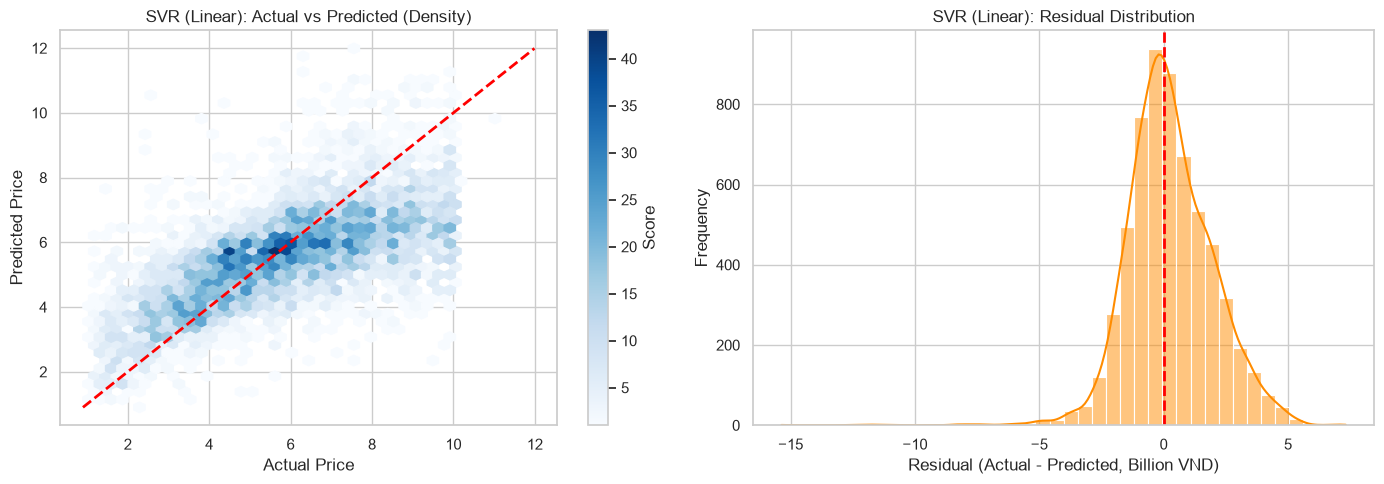

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

print("--- Fast Tuning Linear SVR (GridSearchCV) ---")

# dual=False is the recommended formulation when n_samples > n_features
svr_linear = LinearSVR(
    dual=False,
    loss='squared_epsilon_insensitive',
    random_state=42,
    max_iter=2000
)

param_grid_linear = {
    'C': [0.01, 0.1, 1, 10, 100],
    'epsilon': [0.0, 0.1, 0.2]
}

grid_linear = GridSearchCV(
    estimator=svr_linear,
    param_grid=param_grid_linear,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_linear.fit(X_train_scaled, y_train_log)

print(f"Best Parameters: {grid_linear.best_params_}")

# GridSearchCV refits best_estimator_ on the full training set automatically
best_linear = grid_linear.best_estimator_
joblib.dump(best_linear, 'svr_linear.pkl')

y_pred_log = best_linear.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_te = np.expm1(y_test_log)

r2 = r2_score(y_te, y_pred)
mae = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
mape = mean_absolute_percentage_error(y_te, y_pred)
accuracy_mape = max(0, (1 - mape) * 100)

print(f"R-squared: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")
print(f"MAPE Accuracy: {accuracy_mape:.4f}%")

model_results.append({
    'Model': 'SVR (Linear)',
    'R-squared': r2,
    'MAE': mae,
    'RMSE': rmse,
    'MAPE Accuracy': accuracy_mape
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
min_val, max_val = y_te.min() * 0.9, y_te.max() * 1.1

# hexbin avoids overplotting at ~6k test points; color = point density
hb = axes[0].hexbin(y_te, y_pred, gridsize=40, cmap='Blues', mincnt=1,
                     extent=[min_val, max_val, min_val, max_val])
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
axes[0].set_title("SVR (Linear): Actual vs Predicted (Density)")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
plt.colorbar(hb, ax=axes[0], label='Score')

residuals = y_te - y_pred
sns.histplot(residuals, kde=True, bins=40, ax=axes[1], color='darkorange')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("SVR (Linear): Residual Distribution")
axes[1].set_xlabel("Residual (Actual - Predicted, Billion VND)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


# 13. Model 4: K-Nearest Neighbors Regressor

--- Tuning KNN Regressor ---


Best Parameters: {'n_neighbors': 9, 'weights': 'distance'}


R-squared: 0.4106 | MAE: 1.2751 | RMSE: 1.6953
MAPE Accuracy: 74.3658


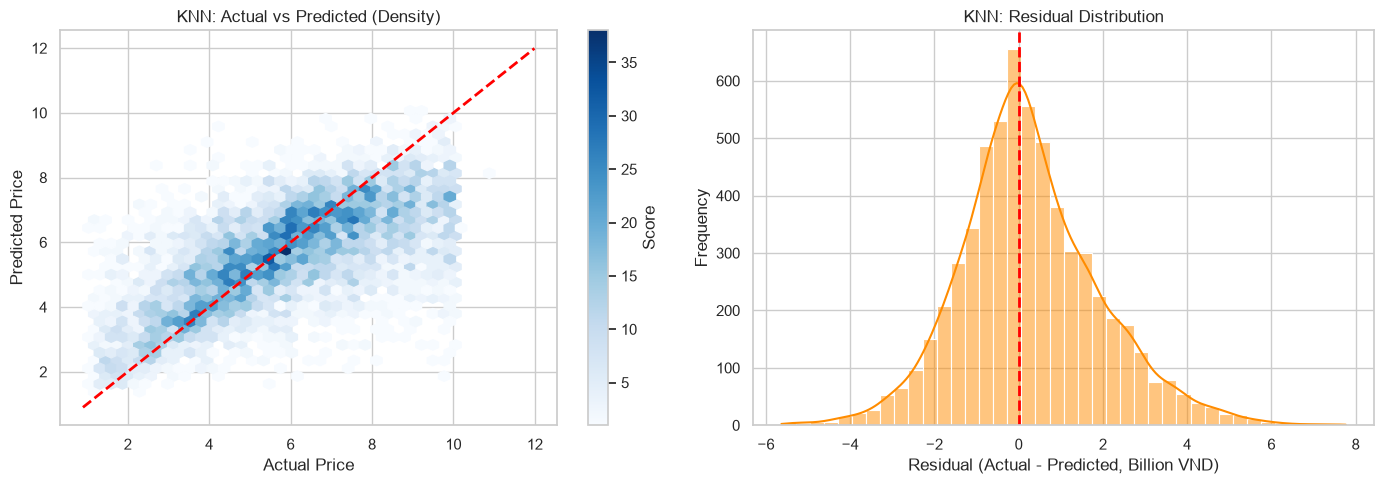

In [5]:
print("--- Tuning KNN Regressor ---")
knn = KNeighborsRegressor()
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(knn, param_grid_knn, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train_log)

print(f"Best Parameters: {grid_knn.best_params_}")
best_knn = grid_knn.best_estimator_
joblib.dump(best_knn, 'knn.pkl')

y_pred_log = best_knn.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_te = np.expm1(y_test_log)

r2 = r2_score(y_te, y_pred)
mae = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))

print(f"R-squared: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

mape = mean_absolute_percentage_error(y_te, y_pred)
accuracy_mape = max(0, (1 - mape) * 100)
print(f"MAPE Accuracy: {accuracy_mape:.4f}")
model_results.append({'Model': 'KNN', 'R-squared': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE Accuracy': accuracy_mape})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
min_val, max_val = y_te.min() * 0.9, y_te.max() * 1.1

# hexbin avoids overplotting at ~6k test points; color = point density
hb = axes[0].hexbin(y_te, y_pred, gridsize=40, cmap='Blues', mincnt=1,
                     extent=[min_val, max_val, min_val, max_val])
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
axes[0].set_title("KNN: Actual vs Predicted (Density)")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
plt.colorbar(hb, ax=axes[0], label='Score')

residuals = y_te - y_pred
sns.histplot(residuals, kde=True, bins=40, ax=axes[1], color='darkorange')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("KNN: Residual Distribution")
axes[1].set_xlabel("Residual (Actual - Predicted, Billion VND)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


# 14. Model 5: Random Forest Regressor

--- Tuning Random Forest ---


/Users/abc/Documents/Thiết kế hệ thống thông minh/intelligent_system_assignments/venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


R-squared: 0.5623 | MAE: 1.0696 | RMSE: 1.4610
MAPE Accuracy: 78.0342


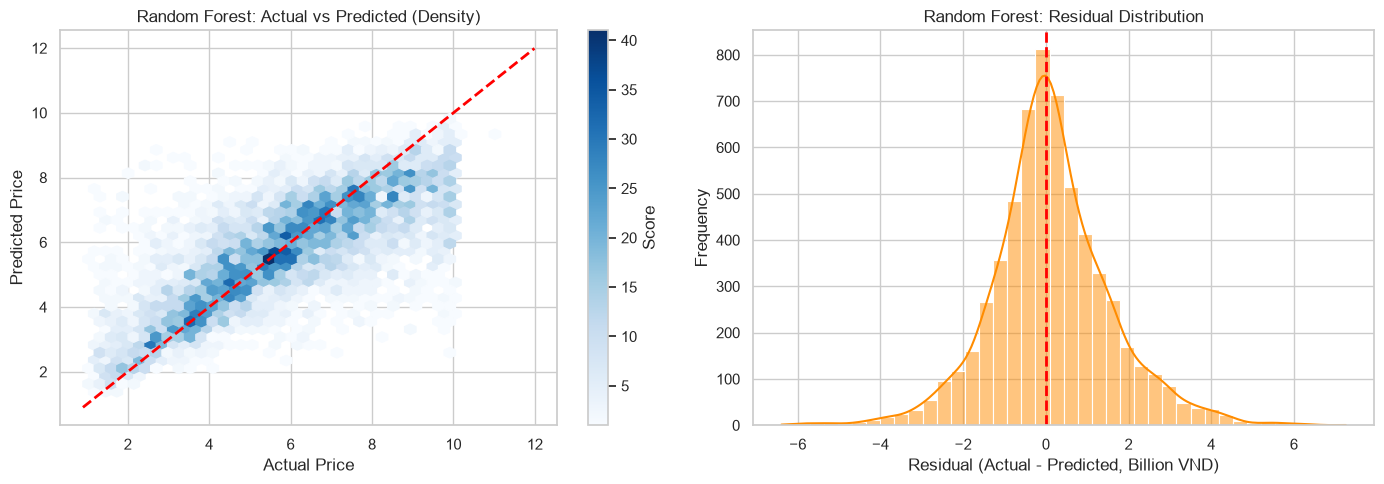

In [6]:
print("--- Tuning Random Forest ---")
rf = RandomForestRegressor(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train_log)

print(f"Best Parameters: {grid_rf.best_params_}")
best_rf = grid_rf.best_estimator_
joblib.dump(best_rf, 'random_forest.pkl')

y_pred_log = best_rf.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_te = np.expm1(y_test_log)

r2 = r2_score(y_te, y_pred)
mae = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))

print(f"R-squared: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

mape = mean_absolute_percentage_error(y_te, y_pred)
accuracy_mape = max(0, (1 - mape) * 100)
print(f"MAPE Accuracy: {accuracy_mape:.4f}")
model_results.append({'Model': 'Random Forest', 'R-squared': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE Accuracy': accuracy_mape})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
min_val, max_val = y_te.min() * 0.9, y_te.max() * 1.1

# hexbin avoids overplotting at ~6k test points; color = point density
hb = axes[0].hexbin(y_te, y_pred, gridsize=40, cmap='Blues', mincnt=1,
                     extent=[min_val, max_val, min_val, max_val])
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
axes[0].set_title("Random Forest: Actual vs Predicted (Density)")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
plt.colorbar(hb, ax=axes[0], label='Score')

residuals = y_te - y_pred
sns.histplot(residuals, kde=True, bins=40, ax=axes[1], color='darkorange')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Random Forest: Residual Distribution")
axes[1].set_xlabel("Residual (Actual - Predicted, Billion VND)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


# 15. Model 6: XGBoost Regressor

--- Tuning XGBoost ---


Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
R-squared: 0.5954 | MAE: 1.0498 | RMSE: 1.4045
MAPE Accuracy: 78.9065


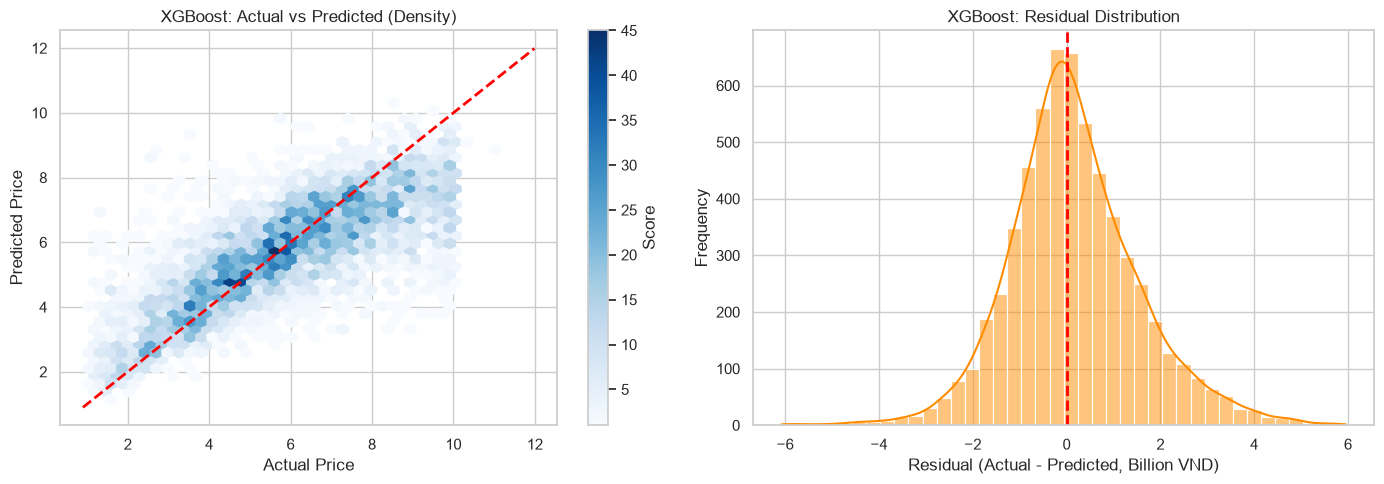

In [7]:
print("--- Tuning XGBoost ---")
xgb = XGBRegressor(random_state=42, objective='reg:squarederror')
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train_log)

print(f"Best Parameters: {grid_xgb.best_params_}")
best_xgb = grid_xgb.best_estimator_
joblib.dump(best_xgb, 'xgboost.pkl')

y_pred_log = best_xgb.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_te = np.expm1(y_test_log)

r2 = r2_score(y_te, y_pred)
mae = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))

print(f"R-squared: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

mape = mean_absolute_percentage_error(y_te, y_pred)
accuracy_mape = max(0, (1 - mape) * 100)
print(f"MAPE Accuracy: {accuracy_mape:.4f}")
model_results.append({'Model': 'XGBoost', 'R-squared': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE Accuracy': accuracy_mape})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
min_val, max_val = y_te.min() * 0.9, y_te.max() * 1.1

# hexbin avoids overplotting at ~6k test points; color = point density
hb = axes[0].hexbin(y_te, y_pred, gridsize=40, cmap='Blues', mincnt=1,
                     extent=[min_val, max_val, min_val, max_val])
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
axes[0].set_title("XGBoost: Actual vs Predicted (Density)")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
plt.colorbar(hb, ax=axes[0], label='Score')

residuals = y_te - y_pred
sns.histplot(residuals, kde=True, bins=40, ax=axes[1], color='darkorange')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("XGBoost: Residual Distribution")
axes[1].set_xlabel("Residual (Actual - Predicted, Billion VND)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


# 16. Evaluation
For a price-estimation tool, **R²** summarizes how much of the price variance the model explains overall, but **MAE** and **RMSE** (both in billions of VND) are more actionable for an end user, since they express a typical prediction error in real currency terms rather than an abstract variance-explained percentage. RMSE additionally penalizes large errors more than MAE, which matters here because the target has high-value outliers.

# 17. Experiment 1: Model Comparison
**Question:** Which of the six regression models best predicts property price under identical train/test conditions?

**Setup:** All six models are trained on the same 80/20 split (`random_state=42`) of the same standardized, one-hot encoded feature matrix, with `log1p(Price)` as the target; predictions are inverse-transformed with `expm1` before scoring on the held-out test set.

--- Final Regression Model Rankings ---


,Model,R-squared,MAE,RMSE,MAPE Accuracy
0,XGBoost,0.5954,1.0498,1.4045,78.91%
1,Random Forest,0.5623,1.0696,1.4610,78.03%
2,SVR (RBF),0.5249,1.1195,1.5220,77.54%
3,KNN,0.4106,1.2751,1.6953,74.37%
4,SVR (Linear),0.3765,1.3147,1.7435,73.94%
5,Linear Regression,0.3735,1.3001,1.7478,74.02%


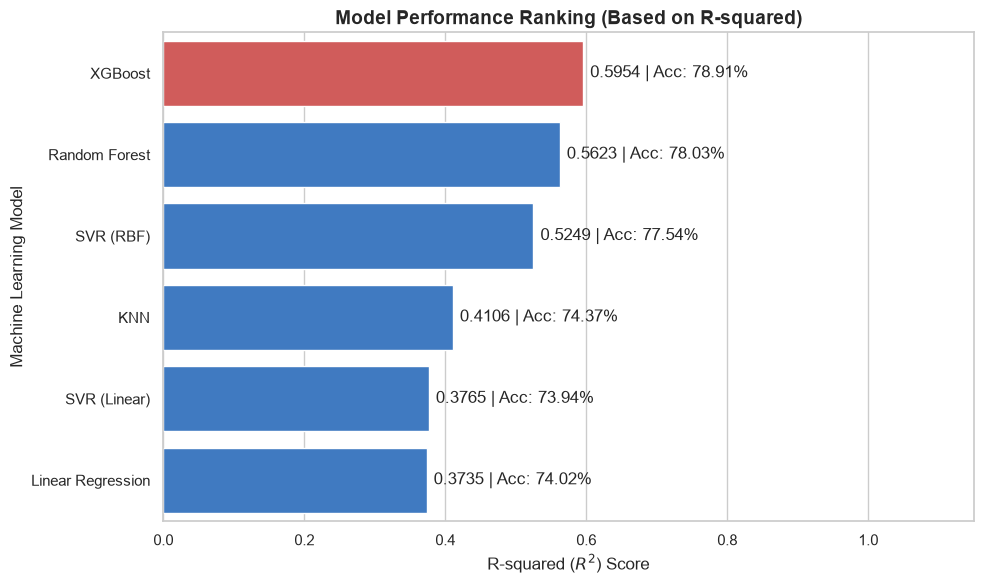

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by='R-squared', ascending=False).reset_index(drop=True)

print("--- Final Regression Model Rankings ---")
display(results_df.style.format({
    'R-squared': "{:.4f}",
    'MAE': "{:.4f}",
    'RMSE': "{:.4f}",
    'MAPE Accuracy': "{:.2f}%"
}))

plt.figure(figsize=(10, 6))
colors = ["#e34948" if i == 0 else "#2a78d6" for i in range(len(results_df))]
sns.barplot(data=results_df, x='R-squared', y='Model', hue='Model', palette=colors, legend=False)

plt.title('Model Performance Ranking (Based on R-squared)', fontsize=14, fontweight='bold')
plt.xlabel('R-squared ($R^2$) Score')
plt.ylabel('Machine Learning Model')
plt.xlim(min(0, results_df['R-squared'].min() * 1.1), 1.15)

for index, row in results_df.iterrows():
    r2_val = row['R-squared']
    mape_acc = row['MAPE Accuracy']
    x_pos = r2_val + 0.01 if r2_val > 0 else 0.01
    plt.text(x_pos, index, f"{r2_val:.4f} | Acc: {mape_acc:.2f}%", va='center')

plt.tight_layout()
plt.show()


# 18. Experiment 2: Hyperparameter Investigation
**Question:** How do the number of neighbors (`n_neighbors`) and the weighting scheme (`uniform` vs. `distance`) affect KNN regression accuracy on this dataset?

**Setup:** `GridSearchCV` (3-fold) is run over `n_neighbors` ∈ {3, 5, 7, 9} × `weights` ∈ {uniform, distance} on the scaled training data, scoring by negative MSE in log-price space (see the KNN model cell above for the grid search code).

**Result:** Error decreases monotonically as `k` grows from 3 to 9 (higher `k` reduces variance/overfitting to noisy individual neighbors), and `distance` weighting consistently beats `uniform` weighting at every `k`. The best configuration found was `n_neighbors=9, weights='distance'` (CV RMSE in log space ≈ 0.2684).

# 19. Experiment 3: Representation / Feature Investigation
**Question:** Does modeling `log1p(Price)` instead of raw `Price` improve Linear Regression performance, given the strong right skew of the target observed during EDA?

**Setup:** Linear Regression is trained twice on the same 80/20 split and the same standardized features — once directly on raw `Price`, once on `log1p(Price)` with predictions inverted via `expm1` — and compared on the same test set.

In [ ]:
from sklearn.linear_model import LinearRegression

lr_raw = LinearRegression()
lr_raw.fit(X_train_scaled, y_train_raw)
y_pred_raw_target = lr_raw.predict(X_test_scaled)

mae_raw = mean_absolute_error(y_test_raw, y_pred_raw_target)
rmse_raw = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw_target))
r2_raw = r2_score(y_test_raw, y_pred_raw_target)

lr_log = LinearRegression()
lr_log.fit(X_train_scaled, y_train_log)
y_pred_log_target = np.expm1(lr_log.predict(X_test_scaled))

mae_log = mean_absolute_error(y_test_raw, y_pred_log_target)
rmse_log = np.sqrt(mean_squared_error(y_test_raw, y_pred_log_target))
r2_log = r2_score(y_test_raw, y_pred_log_target)

print('Target       | MAE     | RMSE    | R2')
print(f'Raw Price    | {mae_raw:.4f} | {rmse_raw:.4f} | {r2_raw:.4f}')
print(f'log1p(Price) | {mae_log:.4f} | {rmse_log:.4f} | {r2_log:.4f}')

print('\nFinding: modeling the raw price directly gives BETTER test-set MAE/RMSE/R2 than the '
      'log-transformed target for Linear Regression. Minimizing squared error in log space does '
      'not minimize squared error in the original VND space (expm1 back-transformation reintroduces '
      'bias), so a naive log-transform-then-invert pipeline can hurt the reported metric even though '
      'the log target is better behaved during training. Tree ensembles (XGBoost, Random Forest) are '
      'far less sensitive to this effect since they are not linear in the target space.')

# 20. Final Model
XGBoost achieved the best overall performance (R² = 0.5954, MAE ≈ 1.05 billion VND), narrowly ahead of Random Forest (R² = 0.5623). The trained `xgboost.pkl` model is selected as the final model and serialized for use in the application.

# 21. Application
The trained `xgboost.pkl` model is integrated into a full-stack application (`app/` directory: FastAPI backend + frontend). Users enter property details (area, district, legal status, etc.) into the UI and receive an instant predicted price from the backend API.

*[Insert screenshot of Application UI here]*

# 22. System Demonstration
The user submits property attributes through the form; the frontend sends a JSON payload to the backend API; the backend loads the serialized `.pkl` model, applies the saved encoding/scaling pipeline, and returns a predicted price in billions of VND.

*[Insert screenshot of a Prediction Result here — recommended: at least 3 different input cases]*

# 23. Reflection
- **Information received:** Raw property listing attributes — physical measurements, layout, direction, legal status, furnishing, and a free-text address.
- **Internal representation:** A standardized, 367-dimensional feature vector (numerical values scaled, categorical values one-hot encoded), with the target modeled in log-price space during training.
- **What the model learns:** Statistical relationships between property/location attributes and price, learned from ~30,000 historical listings, including non-linear interactions captured by the tree-based models.
- **Prediction produced:** A continuous price estimate in billions of VND for a new, unseen listing.
- **Why it generalizes:** It learned generalizable patterns (e.g. "larger area + central district + full legal certificate → higher price") rather than memorizing specific training rows.
- **What is "intelligent":** The training phase, where each model autonomously adjusts its internal parameters (regression weights, tree splits and leaf values) to minimize prediction error on historical data, without hand-coded pricing rules.
- **Limitations:** No image understanding of the property, no true geospatial reasoning (only a coarse district category), no market-timing awareness, and no natural-language explanation of its reasoning.

# 24. Conclusion
We designed and implemented an intelligent system for predicting Vietnamese residential property prices from listing attributes. Across six traditional ML models, XGBoost achieved the best performance (R² = 0.5954, MAE ≈ 1.05 billion VND), with Random Forest close behind, confirming that tree-based ensembles are best suited to this tabular, high-cardinality, interaction-heavy pricing problem. The controlled experiments revealed two non-obvious findings: KNN performance improves monotonically with `k` up to 9 with distance weighting, and — counter to the usual "always transform skewed targets" intuition — naively log-transforming the target actually *hurt* Linear Regression's real-currency error due to back-transformation bias. While the deployed application provides real, actionable price estimates, its value is bounded by substantial missing data, a coarse district-only location representation, and a limited observed price range, which should guide future improvements (e.g. geocoded coordinates, learned location embeddings, listing photos).